In [268]:
# Imports
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

In [269]:
# Import timestamp results
makespan_best_case_baseline_df = pd.read_csv(filepath_or_buffer="../timestamp_results/bc-50-orders-completed-orders-#0.csv", header=0, sep=',', dtype=np.longlong)
makespan_worst_case_baseline_df = pd.read_csv(filepath_or_buffer="../timestamp_results/wc-50-orders-completed-orders-#0.csv", header=0, sep=',', dtype=np.longlong)
reconfigure_df = pd.read_csv(filepath_or_buffer="../timestamp_results/reconfigure-50-orders-completed-orders-#0.csv", header=0, sep=',', dtype=np.longlong)
rearrange_df = pd.read_csv(filepath_or_buffer="../timestamp_results/rearrange-50-orders-completed-orders-#0.csv", header=0, sep=',', dtype=np.longlong)

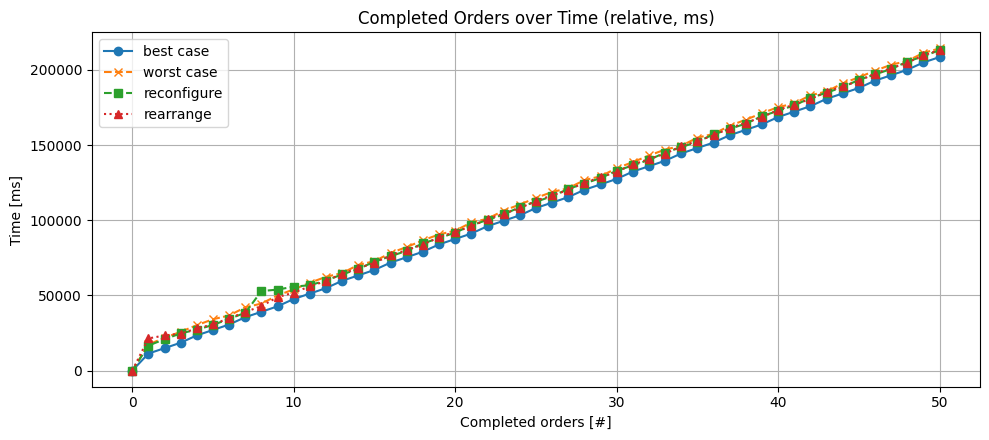

In [270]:
# ensure rel_ms exists for reconfigure and rearrange (baseline already has it)
makespan_best_case_baseline_start_ts = makespan_best_case_baseline_df['TIMESTAMP'].iloc[0]
makespan_best_case_baseline_df['rel_ms'] = (makespan_best_case_baseline_df['TIMESTAMP'] - makespan_best_case_baseline_start_ts) / 1e6
makespan_worst_case_baseline_start_ts = makespan_worst_case_baseline_df['TIMESTAMP'].iloc[0]
makespan_worst_case_baseline_df['rel_ms'] = (makespan_worst_case_baseline_df['TIMESTAMP'] - makespan_worst_case_baseline_start_ts) / 1e6
reconfigure_start_ts = reconfigure_df['TIMESTAMP'].iloc[0]
reconfigure_df['rel_ms'] = (reconfigure_df['TIMESTAMP'] - reconfigure_start_ts) / 1e6
rearrange_start_ts = rearrange_df['TIMESTAMP'].iloc[0]
rearrange_df['rel_ms'] = (rearrange_df['TIMESTAMP'] - rearrange_start_ts) / 1e6

# Plot all three with legend
plt.figure(figsize=(10, 4.5))
plt.plot(makespan_best_case_baseline_df['COMPLETED_ORDER_COUNT'], makespan_best_case_baseline_df['rel_ms'],
        marker='o', linestyle='-', label='best case')
plt.plot(makespan_worst_case_baseline_df['COMPLETED_ORDER_COUNT'], makespan_worst_case_baseline_df['rel_ms'],
        marker='x', linestyle='--', label='worst case')
plt.plot(reconfigure_df['COMPLETED_ORDER_COUNT'], reconfigure_df['rel_ms'],
         marker='s', linestyle='--', label='reconfigure')
plt.plot(rearrange_df['COMPLETED_ORDER_COUNT'], rearrange_df['rel_ms'],
         marker='^', linestyle=':', label='rearrange')

plt.xlabel('Completed orders [#]')
plt.ylabel('Time [ms]')
plt.title('Completed Orders over Time (relative, ms)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [271]:
print("best case baseline makespan: {0} ms".format(makespan_best_case_baseline_df['rel_ms'].iloc[-1]))
print("worst case baseline makespan: {0} ms, {1}% slower than best case".format(makespan_worst_case_baseline_df['rel_ms'].iloc[-1], (1-makespan_best_case_baseline_df['rel_ms'].iloc[-1]/makespan_worst_case_baseline_df['rel_ms'].iloc[-1])*1e2))
print("reconfigure makespan: {0} ms, {1}% faster than worst case".format(reconfigure_df['rel_ms'].iloc[-1], (1-reconfigure_df['rel_ms'].iloc[-1]/makespan_worst_case_baseline_df['rel_ms'].iloc[-1])*1e2))
print("rearrange makespan: {0} ms, {1}% faster than worst case".format(rearrange_df['rel_ms'].iloc[-1], (1-rearrange_df['rel_ms'].iloc[-1]/makespan_worst_case_baseline_df['rel_ms'].iloc[-1])*1e2))

best case baseline makespan: 208601.437231 ms
worst case baseline makespan: 214334.472355 ms, 2.674807771707599% slower than best case
reconfigure makespan: 213217.741196 ms, 0.5210226552592956% faster than worst case
rearrange makespan: 213323.863157 ms, 0.4715103393756137% faster than worst case


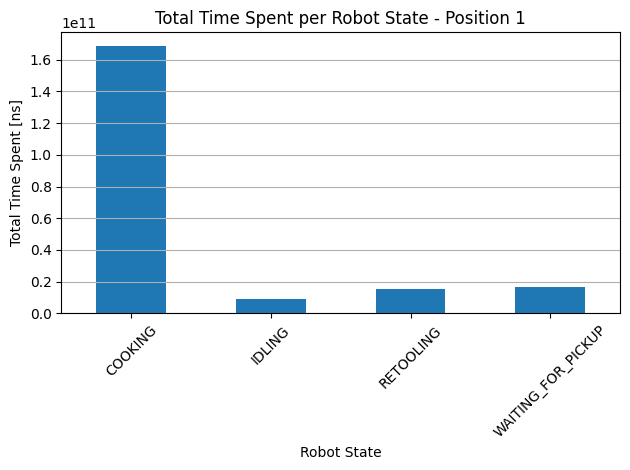

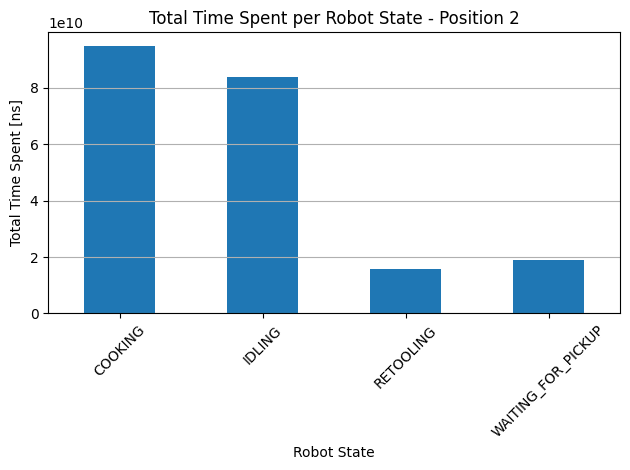

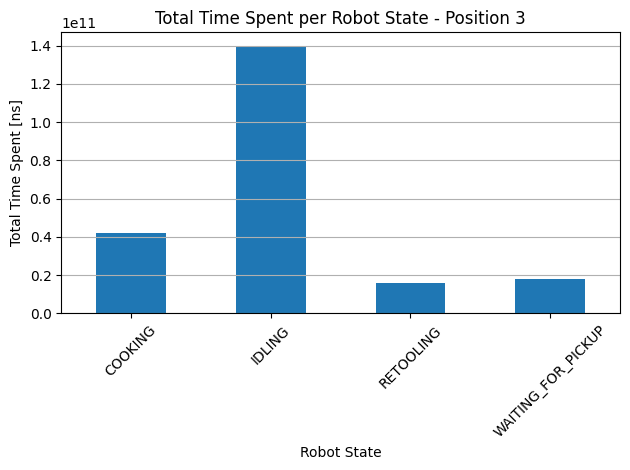

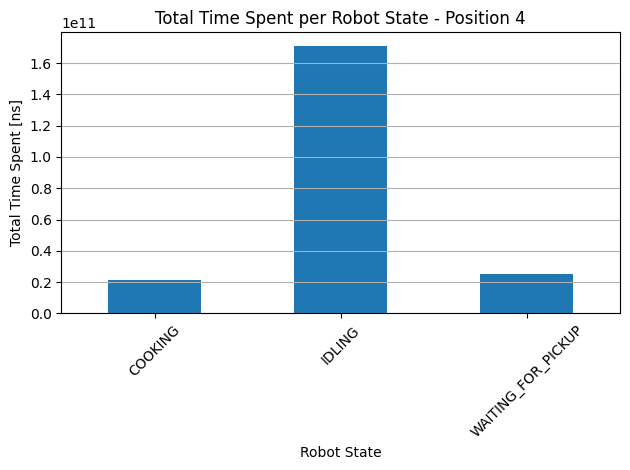

Total time recorded for Position 1: 210.57 seconds
Total time recorded for Position 1 without IDLING: 201.43 seconds
Total time recorded for Position 2: 213.66 seconds
Total time recorded for Position 2 without IDLING: 129.75 seconds
Total time recorded for Position 3: 215.82 seconds
Total time recorded for Position 3 without IDLING: 75.90 seconds
Total time recorded for Position 4: 217.23 seconds
Total time recorded for Position 4 without IDLING: 46.15 seconds


In [272]:
from enum import IntEnum

# State enums
class RobotState(IntEnum):
    IDLING = 0
    COOKING = 1
    RETOOLING = 2
    WAITING_FOR_PICKUP = 3
    REARRANGING = 4
    RECONFIGURING = 5

# helper mapping from numeric state to name
ROBOT_STATE_NAME = {state.value: state.name for state in RobotState}

# Method to analyze time spent in each state per robot position
def analyze_time_spent_per_state(robot_stats_df):
    # Print the time spent in each state for position 1
    t0 = robot_stats_df['TIMESTAMP'].iloc[0]
    robot_stats_df['rel_ns'] = robot_stats_df['TIMESTAMP'] - t0
    robot_times_spent_df = pd.DataFrame({
        'STATE_NAME': pd.Series(dtype='object'),
        'DURATION_NS': pd.Series(dtype='int64')
    })

    state_key = robot_stats_df['STATE'].iloc[0]
    start_time = robot_stats_df['rel_ns'].iloc[0]

    for index, row in robot_stats_df.iterrows():
        if row['STATE'] != state_key:
            end_time = row['rel_ns']
            time_in_state = end_time - start_time
            state_name = ROBOT_STATE_NAME[state_key]

            # append a row
            robot_times_spent_df = pd.concat(
                [
                    robot_times_spent_df,
                    pd.DataFrame(
                        {'STATE_NAME': [state_name], 'DURATION_NS': [time_in_state]}
                    )
                ],
                ignore_index=True,
            )

            state_key = row['STATE']
            start_time = row['rel_ns']

    # handle last segment until the last timestamp
    end_time = robot_stats_df['rel_ns'].iloc[-1]
    time_in_state = end_time - start_time
    state_name = ROBOT_STATE_NAME[state_key]
    robot_times_spent_df = pd.concat(
        [
            robot_times_spent_df,
            pd.DataFrame({'STATE_NAME': [state_name], 'DURATION_NS': [time_in_state]})
        ],
        ignore_index=True,
    )
    return robot_times_spent_df

# Import best case statistics results
statistics_bc_baseline_df = pd.read_csv(filepath_or_buffer="../statistic_results/bc-50-orders-robot-statistics-#0.csv", header=0, sep=',', dtype=np.longlong)
# Extract positions
pos_1_df = statistics_bc_baseline_df[statistics_bc_baseline_df['ROBOT_POSITION'] == 1].copy()
pos_2_df = statistics_bc_baseline_df[statistics_bc_baseline_df['ROBOT_POSITION'] == 2].copy()
pos_3_df = statistics_bc_baseline_df[statistics_bc_baseline_df['ROBOT_POSITION'] == 3].copy()
pos_4_df = statistics_bc_baseline_df[statistics_bc_baseline_df['ROBOT_POSITION'] == 4].copy()

time_spent_dfs = [analyze_time_spent_per_state(pos_df) for pos_df in [pos_1_df, pos_2_df, pos_3_df, pos_4_df]]
aggregated_time_spent_dfs = []
for time_spent_df in time_spent_dfs:
    aggregated_df = (
        time_spent_df
        .groupby('STATE_NAME', as_index=False)['DURATION_NS']
        .sum()
    )
    aggregated_time_spent_dfs.append(aggregated_df)

for i, aggregated_df in enumerate(aggregated_time_spent_dfs):
    ax = aggregated_df.plot.bar(x='STATE_NAME', y='DURATION_NS', legend=False, title=f'Total Time Spent per Robot State - Position {i+1}')
    ax.set_xlabel('Robot State')
    ax.set_ylabel('Total Time Spent [ns]')
    plt.xticks(rotation=45)
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

# Sum up total time
for i, aggregated_df in enumerate(aggregated_time_spent_dfs):
    total_time_ns = aggregated_df['DURATION_NS'].sum()
    print(f"Total time recorded for Position {i+1}: {total_time_ns / 1e9:.2f} seconds")
    total_time_without_idling_ns = aggregated_df[aggregated_df['STATE_NAME'] != 'IDLING']['DURATION_NS'].sum()
    print(f"Total time recorded for Position {i+1} without IDLING: {total_time_without_idling_ns / 1e9:.2f} seconds")

In [273]:
# statistics_wc_baseline_df = pd.read_csv(filepath_or_buffer="../statistic_results/wc-50-orders-robot-statistics-#0.csv", header=0, sep=',', dtype=np.longlong)
# statistics_reconfigure_df = pd.read_csv(filepath_or_buffer="../statistic_results/reconfigure-50-orders-robot-statistics-#0.csv", header=0, sep=',', dtype=np.longlong)
# statistics_rearrange_df = pd.read_csv(filepath_or_buffer="../statistic_results/rearrange-50-orders-robot-statistics-#0.csv", header=0, sep=',', dtype=np.longlong)